# Notes for linear regression
*   Linear regression is a type of supervised learning, i.e. need data set including the prediction.
*   It may seem dull, but it is useful and still WIDELY used.
*   Many fancy statistical learning approaches can be seen as generalizaions or extensions of linear regression.
*   Least squares approach is the most common way of assessing the model.

# Common format of linear regression
$$
Y \approx \beta_0 + \beta_1 X
$$ 
# Residual sum of squares (RSS)
$$
RSS = e_1^2 + e_2^2 +...+ e_n^2
$$
where 
$$
e_n = (y_n - \hat\beta_0 - \hat\beta_1 x_n)^2
$$
Thus,
$$
RSS = (y_1 - \hat\beta_0 - \hat\beta_1 x_1)^2 + (y_2 - \hat\beta_0 - \hat\beta_1 x_2)^2 + ... + (y_n - \hat\beta_0 - \hat\beta_1 x_n)^2
$$

Take derivatives about $\beta_0$ and $\beta_1$ respectively to minimize the RSS, then we will have:
$$
\hat\beta_1 = \frac{\sum_{i=1}^{n} (x_i - \bar x)(y_i-\bar y)}{\sum_{i=1}^{n} (x_i - \bar x)^2}
$$

$$
\hat\beta_0 = \bar y - \hat\beta_1 \bar x
$$
where $ \bar y = \frac{1}{n} \sum_{i=1}^n y_i $ and $ \bar x = \frac{1}{n} \sum_{i=1}^n x_i$.
<br>
<br>
### For a TV advertising example, y is the number of sales and x is \$ spent on advertising. When $\hat\beta_0 = 7.03 $ and $\hat\beta_1 = 0.0745$, it tells that $1,000 spent on TV AD is associated with selling approximately 74.5 additional units and without any cost, 7 units is likely to be sold. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd     

In [14]:
#Read in data
data=pd.read_csv('Study_Performance_LR_Example.csv')
print(data.head())
print(data.shape)

   Hours of Study   Expected Marks
0       32.502345        31.707006
1       53.426804        68.777596
2       61.530358        62.562382
3       47.475640        71.546632
4       59.813208        87.230925
(100, 2)


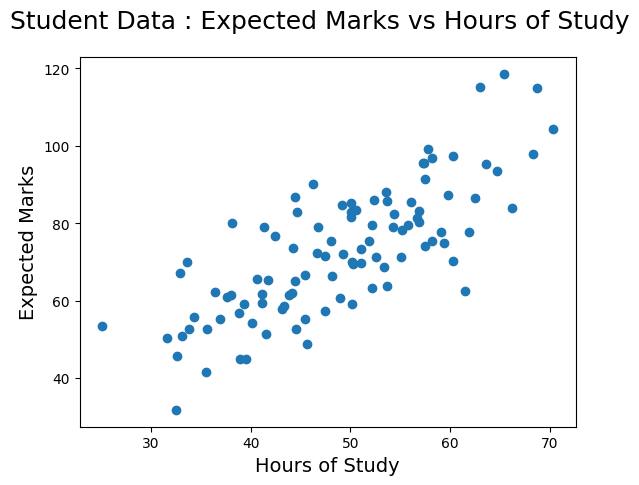

In [22]:
fig = plt.figure()
plt.scatter(data.iloc[:,0], data.iloc[:,1])
fig.suptitle('Student Data : Expected Marks vs Hours of Study', fontsize=18)
plt.xlabel('Hours of Study', fontsize=14)
plt.ylabel('Expected Marks', fontsize=14)
plt.show()

In [25]:
def loss(m,b,X,Y):
  N = float(len(X))
  return(sum(0.5*((m*X+b)-Y)**2)/N)
  
def gradient_descent (m, b, X, Y, learning_rate, max_iteration) :
  learning_ratem = learning_rate[0]
  learning_rateb = learning_rate[1]
  for i in range(max_iteration):
    #XY = [a1*a2 for a1,a2 in zip(X,Y)]
    #Xsqr = [a**2 for a in X]
    N = float(len(X))
    #dm, db = [-m*sum(Xsqr)/N-b*sum(X)/N+sum(XY)/N , -b+m*sum(X)/N+sum(Y)/N]
    dm, db = [sum(X * (Y - m*X-b))/N, sum(Y - m*X-b)/N]
    m = m + learning_ratem * dm
    b = b + learning_rateb * db
    if i % 1000 == 0 :
      print ('iteration : ', i, ' loss : ', loss(m, b, X, Y),' ',dm,'',db)
  return (m, b)

In [26]:
X = data.iloc[:,0]
Y = data.iloc[:,1]
m = 0
b = 0
learning_rate = [0.0001,1]
max_iteration = 10000
m, b = gradient_descent (m, b, X, Y, learning_rate, max_iteration)

iteration :  0  loss :  260.6864831458747   3685.3514867955273  72.73505055368646
iteration :  1000  loss :  55.12870401360229   0.038977111880385405  -0.00019228196072241133
iteration :  2000  loss :  55.12869173310963   1.943660173147177e-05  -9.58846753018605e-08
iteration :  3000  loss :  55.12869173310658   9.692575432262984e-09  -4.781027129752147e-11
iteration :  4000  loss :  55.12869173310658   4.9762316489676554e-12  -2.1831425556229077e-14
iteration :  5000  loss :  55.12869173310658   1.1068468364072715e-12  -1.1546319456101628e-16
iteration :  6000  loss :  55.12869173310658   1.1068468364072715e-12  -1.1546319456101628e-16
iteration :  7000  loss :  55.12869173310658   1.1068468364072715e-12  -1.1546319456101628e-16
iteration :  8000  loss :  55.12869173310658   1.1068468364072715e-12  -1.1546319456101628e-16
iteration :  9000  loss :  55.12869173310658   1.1068468364072715e-12  -1.1546319456101628e-16


In [27]:
print(m,b)
np_m, np_b = np.polyfit(X, Y, 1)
print(np_m,np_b)
print(loss(np_m,np_b,X,Y))

1.3224310227553477 7.9910209822709755
1.3224310227553593 7.991020982270413
55.12869173310658


1.3224310227553593 7.991020982270413


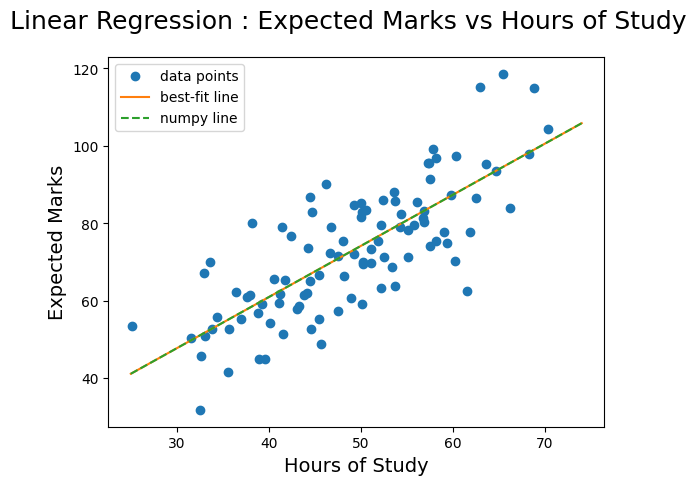

In [28]:
np_m, np_b = np.polyfit(X, Y, 1)
print(np_m,np_b)
fig = plt.figure()
x = np.arange(25, 75)
# Generate data for plotting Line
x = np.arange(25, 75)
y = [m * x_i + b for x_i in x]

# Generate data for plotting Line Numpy Linear Regression
np_x = np.arange(25, 75)
np_y = [np_m * x_i + np_b for x_i in np_x]

# plot data and best-fit lines
plt.plot(X, Y, 'o', x, y, '-', np_x, np_y, '--')
plt.legend(loc='upper left', labels=['data points', 'best-fit line', 'numpy line'])

fig.suptitle('Linear Regression : Expected Marks vs Hours of Study', fontsize=18)
plt.xlabel('Hours of Study', fontsize=14)
plt.ylabel('Expected Marks', fontsize=14)
plt.show()